In [1]:
import velot
import scanpy as sc
import scvelo as scv

# Load and preprocess
adata = velot.datasets.synthetic_cycle((1000, 2000, 4000, 2000), n_rotations=3, x_amplitude=3, z_drift=20, noise_level=0.3, extra_dimensions=1)
adata.obs["clusters_id"] = adata.obs["celltype"].cat.codes
velot.pp.pseudotime(adata, key="true_pseudotime")

# Define transitions
edges = [
    ('Phase_1', 'Phase_2'),
    ('Phase_2', 'Phase_3'), 
    ('Phase_3', 'Phase_4')
]

/home/user/miniforge3/envs/velot/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
# Everything in one grid search — including PCA dimensions
results = velot.tl.gridsearch(
    adata=adata,
    param_grid={
        "reg": [0.01, 0.05, 0.1],
        "lambda_smooth": [0.1, 0.5, 1.0],
        "lambda_curl": [0.1, 0.5, 1.0],
        "window_size": [50, 100, 200],
        "overlap_fraction": [0.0, 0.05, 0.1]
    },
    cluster_edges=edges,
    cluster_key="celltype",
    fixed_params={
        "basis": "X_pca",
        "smooth": True,
        "n_epochs": 500,
        "n_clusters": None,
        "spatial_key": "clusters_id",
        "project_umap": True
    },
    verbose=True
)

VelOT Grid Search: 243 combinations
  Parameters: ['lambda_curl', 'lambda_smooth', 'overlap_fraction', 'reg', 'window_size']
  Fixed: {'basis': 'X_pca', 'smooth': True, 'n_epochs': 500, 'n_clusters': None, 'spatial_key': 'clusters_id', 'project_umap': True}



VelOT Grid Search:   0%|          | 0/243 [00:00<?, ?it/s, lambda_curl=0.1, lambda_smooth=0.1, overlap_fraction=0, reg=0.01, window_size=50]

  Using precomputed spatial labels from 'clusters_id': 4 clusters
  Built 176 window pairs across 4 clusters (skipped 0 small clusters)
  Window size: 50, step: 50
  OT velocity computed: 8800 cells with velocity, 200 cells without (will be filled by smoothing)
  Velocity projected to UMAP (9000 cells)


VelOT Grid Search:   0%|          | 1/243 [00:14<59:50, 14.84s/it, lambda_curl=0.1, lambda_smooth=0.1, overlap_fraction=0, reg=0.01, window_size=100]                         

    ICCoh=0.914  CBDir=0.872  (10.2s)
  Using precomputed spatial labels from 'clusters_id': 4 clusters
  Built 86 window pairs across 4 clusters (skipped 0 small clusters)
  Window size: 100, step: 100
  OT velocity computed: 8600 cells with velocity, 400 cells without (will be filled by smoothing)
  Velocity projected to UMAP (9000 cells)


...

    ICCoh=0.943  CBDir=0.870  (6.6s)
  Using precomputed spatial labels from 'clusters_id': 4 clusters
  Built 98 window pairs across 4 clusters (skipped 0 small clusters)
  Window size: 100, step: 90
  OT velocity computed: 8860 cells with velocity, 140 cells without (will be filled by smoothing)
  Velocity projected to UMAP (9000 cells)


VelOT Grid Search: 100%|█████████▉| 242/243 [52:02<00:10, 10.48s/it, lambda_curl=1, lambda_smooth=1, overlap_fraction=0.1, reg=0.1, window_size=200]                          

    ICCoh=0.950  CBDir=0.872  (6.4s)
  Using precomputed spatial labels from 'clusters_id': 4 clusters
  Built 47 window pairs across 4 clusters (skipped 0 small clusters)
  Window size: 200, step: 180
  OT velocity computed: 8540 cells with velocity, 460 cells without (will be filled by smoothing)
  Velocity projected to UMAP (9000 cells)


VelOT Grid Search: 100%|██████████| 243/243 [52:11<00:00, 12.89s/it, lambda_curl=1, lambda_smooth=1, overlap_fraction=0.1, reg=0.1, window_size=200, ICCoh=0.943, CBDir=0.871]

    ICCoh=0.943  CBDir=0.871  (6.0s)

Grid Search Complete

Best ICCoh (0.954):
  lambda_curl: 0.5
  lambda_smooth: 1.0
  overlap_fraction: 0.05
  reg: 0.05
  window_size: 100

Best CBDir (0.874):
  lambda_curl: 1.0
  lambda_smooth: 1.0
  overlap_fraction: 0.0
  reg: 0.01
  window_size: 50


In [3]:
results.to_csv("synthetic_cycle_gridsearch.csv", index=False)

In [ ]:
# Visualize
velot.pl.gridsearch_results(
    results, metric="cbdir_mean",
    param_x="reg", param_hue="lambda_smooth",
)

In [9]:
from tqdm.auto import tqdm

results_pca = []
adata_raw = sc.read_h5ad("datasets/endocrinogenesis_day15.5_preprocessed.h5ad")

edges = [
    ('Ngn3 low EP', 'Ngn3 high EP'), 
    ('Ngn3 high EP', 'Fev+'),
    ('Fev+', 'Delta'), 
    ('Fev+', 'Beta'),
    ('Fev+','Epsilon'),
    ('Fev+','Alpha')
]

for n_pcs in tqdm([10, 20], desc="PCA dimensions"):
    adata = adata_raw.copy()
    velot.pp.pca(adata, n_pcs=n_pcs)
    velot.pp.pseudotime(adata, root_cluster="Ngn3 low EP", cluster_key="clusters")
    adata.obs["clusters_id"] = adata.obs["clusters"].cat.codes

    sub_results = velot.tl.gridsearch(
        adata,
        param_grid={
            "reg": [0.01, 0.05],
            "lambda_smooth": [0.1],
            "window_size": [20, 50],
        },
        cluster_edges=edges,
        cluster_key="clusters",
        fixed_params={
            "basis": "X_pca",
            "smooth": True,
            "n_epochs": 200,
            "n_clusters": None,
            "spatial_key": "clusters_id",
            "project_umap": True,
            "overlap_fraction": 0.05,
        },
        verbose=True,  # inner tqdm will show per-combination progress
    )
    sub_results["n_pcs"] = n_pcs
    results_pca.append(sub_results)

PCA dimensions:   0%|          | 0/2 [00:00<?, ?it/s]

VelOT Grid Search: 4 combinations
  Parameters: ['lambda_smooth', 'reg', 'window_size']
  Fixed: {'basis': 'X_pca', 'smooth': True, 'n_epochs': 200, 'n_clusters': None, 'spatial_key': 'clusters_id', 'project_umap': True, 'overlap_fraction': 0.05}

  [1/4] {'lambda_smooth': 0.1, 'reg': 0.01, 'window_size': 20}
  Using precomputed spatial labels from 'clusters_id': 7 clusters
  Built 130 window pairs across 7 clusters (skipped 0 small clusters)
  Window size: 20, step: 19
  OT velocity computed: 2477 cells with velocity, 54 cells without (will be filled by smoothing)
  Velocity projected to UMAP (2531 cells)
    ICCoh=0.452  CBDir=0.697  (2.0s)
  [2/4] {'lambda_smooth': 0.1, 'reg': 0.01, 'window_size': 50}
  Using precomputed spatial labels from 'clusters_id': 7 clusters
  Built 51 window pairs across 7 clusters (skipped 0 small clusters)
  Window size: 50, step: 47
  OT velocity computed: 2389 cells with velocity, 142 cells without (will be filled by smoothing)
  Velocity projected to U

PCA dimensions:  50%|█████     | 1/2 [00:13<00:13, 13.24s/it]

    ICCoh=0.621  CBDir=0.694  (1.8s)

Grid Search Complete

Best ICCoh (0.621):
  lambda_smooth: 0.1
  reg: 0.05
  window_size: 50

Best CBDir (0.697):
  lambda_smooth: 0.1
  reg: 0.01
  window_size: 20
VelOT Grid Search: 4 combinations
  Parameters: ['lambda_smooth', 'reg', 'window_size']
  Fixed: {'basis': 'X_pca', 'smooth': True, 'n_epochs': 200, 'n_clusters': None, 'spatial_key': 'clusters_id', 'project_umap': True, 'overlap_fraction': 0.05}

  [1/4] {'lambda_smooth': 0.1, 'reg': 0.01, 'window_size': 20}
  Using precomputed spatial labels from 'clusters_id': 7 clusters
  Built 130 window pairs across 7 clusters (skipped 0 small clusters)
  Window size: 20, step: 19
  OT velocity computed: 2477 cells with velocity, 54 cells without (will be filled by smoothing)
  Velocity projected to UMAP (2531 cells)
    ICCoh=0.405  CBDir=0.686  (2.1s)
  [2/4] {'lambda_smooth': 0.1, 'reg': 0.01, 'window_size': 50}
  Using precomputed spatial labels from 'clusters_id': 7 clusters
  Built 51 window

PCA dimensions: 100%|██████████| 2/2 [00:27<00:00, 13.69s/it]

    ICCoh=0.533  CBDir=0.699  (2.1s)

Grid Search Complete

Best ICCoh (0.533):
  lambda_smooth: 0.1
  reg: 0.05
  window_size: 50

Best CBDir (0.699):
  lambda_smooth: 0.1
  reg: 0.05
  window_size: 50


In [6]:
# Search over PCA dimensions (requires re-preprocessing)
results_pca = []
adata_raw = sc.read_h5ad("datasets/endocrinogenesis_day15.5_preprocessed.h5ad")

edges = [
    ('Ngn3 low EP', 'Ngn3 high EP'), 
    ('Ngn3 high EP', 'Fev+'),
    ('Fev+', 'Delta'), 
    ('Fev+', 'Beta'),
    ('Fev+','Epsilon'),
    ('Fev+','Alpha')
]

for n_pcs in [10, 20, 30, 50]:
    adata = adata_raw.copy()  # keep a raw copy before PCA

    velot.pp.pca(adata, n_pcs=n_pcs)
    velot.pp.pseudotime(adata, root_cluster="Ngn3 low EP", cluster_key="clusters")
    adata.obs["clusters_id"] = adata.obs["clusters"].cat.codes

    sub_results = velot.tl.gridsearch(
        adata,
        param_grid={
            "reg": [0.01, 0.05, 0.1],
            "lambda_smooth": [0.1, 0.5, 1.0],
            "window_size": [20, 50, 100, 200]
        },
        cluster_edges=edges,
        cluster_key="clusters",
        fixed_params={
            "basis": "X_pca",
            "smooth": True,
            "n_epochs": 200,
            "n_clusters": None,
            "spatial_key": "clusters_id",
            "project_umap": True,
            "overlap_fraction": 0.05
        },
        verbose=False,
    )
    sub_results["n_pcs"] = n_pcs
    results_pca.append(sub_results)

import pandas as pd
all_results = pd.concat(results_pca, ignore_index=True)
print(all_results.sort_values("cbdir_mean", ascending=False).head(10))

  Using precomputed spatial labels from 'clusters_id': 7 clusters
  Built 130 window pairs across 7 clusters (skipped 0 small clusters)
  Window size: 20, step: 19
  OT velocity computed: 2477 cells with velocity, 54 cells without (will be filled by smoothing)
  Velocity projected to UMAP (2531 cells)
  Using precomputed spatial labels from 'clusters_id': 7 clusters
  Built 51 window pairs across 7 clusters (skipped 0 small clusters)
  Window size: 50, step: 47
  OT velocity computed: 2389 cells with velocity, 142 cells without (will be filled by smoothing)
  Velocity projected to UMAP (2531 cells)
  Using precomputed spatial labels from 'clusters_id': 7 clusters
  Built 27 window pairs across 7 clusters (skipped 0 small clusters)
  Window size: 100, step: 95
  OT velocity computed: 2351 cells with velocity, 180 cells without (will be filled by smoothing)
  Velocity projected to UMAP (2531 cells)
  Using precomputed spatial labels from 'clusters_id': 7 clusters
  Built 16 window pairs 

In [7]:
all_results

,lambda_smooth,reg,window_size,iccoh_mean,cbdir_mean,elapsed_seconds,status,cbdir_Fev+_to_Alpha,cbdir_Fev+_to_Beta,cbdir_Fev+_to_Delta,...,cbdir_Ngn3 high EP_to_Fev+,cbdir_Ngn3 low EP_to_Ngn3 high EP,iccoh_Alpha,iccoh_Beta,iccoh_Delta,iccoh_Epsilon,iccoh_Fev+,iccoh_Ngn3 high EP,iccoh_Ngn3 low EP,n_pcs
0,0.1,0.01,20,0.452129,0.696632,1.903019,ok,0.765722,0.879684,0.448214,...,0.898237,0.720548,0.266984,0.158779,0.177025,0.941380,0.558722,0.777737,0.284273,10
1,0.1,0.01,50,0.520299,0.685769,1.488294,ok,0.831260,0.948959,0.440476,...,0.917423,0.476323,0.319159,0.262640,0.150984,0.934139,0.802921,0.905628,0.266619,10
2,0.1,0.01,100,0.570617,0.674517,1.402044,ok,0.851563,0.936176,0.488393,...,0.922180,0.299827,0.396398,0.459855,0.098348,0.902916,0.860830,0.880402,0.395572,10
3,0.1,0.01,200,0.610565,0.640003,1.342946,ok,0.852765,0.932132,0.506803,...,0.915279,0.110486,0.465156,0.520738,0.107567,0.894190,0.872382,0.817291,0.596632,10
4,0.1,0.05,20,0.490480,0.685655,2.445140,ok,0.839848,0.888983,0.456250,...,0.887573,0.669803,0.342679,0.223827,0.315794,0.928003,0.623177,0.749360,0.250518,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,1.0,0.05,200,0.580882,0.656620,2.807428,ok,0.813744,0.949814,0.613393,...,0.925422,0.110525,0.471042,0.607823,0.214308,0.667394,0.862774,0.793230,0.449601,50
140,1.0,0.10,20,0.379925,0.690193,3.000150,ok,0.814278,0.856901,0.515179,...,0.813586,0.786586,0.265406,0.137551,0.206777,0.748082,0.456684,0.556069,0.288909,50
141,1.0,0.10,50,0.475524,0.700401,2.686609,ok,0.833909,0.917110,0.663988,...,0.923004,0.641546,0.391163,0.348120,0.138987,0.838372,0.688256,0.818191,0.105579,50
142,1.0,0.10,100,0.522172,0.655805,2.530344,ok,0.842566,0.937236,0.655060,...,0.920294,0.257861,0.428486,0.553470,0.151225,0.670649,0.810583,0.830759,0.210034,50


     lambda_smooth   reg  window_size  iccoh_mean  cbdir_mean  \
136            1.0  0.05           20    0.380844    0.705085   
124            0.5  0.05           20    0.378543    0.704348   
112            0.1  0.05           20    0.376657    0.704329   
24             1.0  0.01           20    0.464017    0.702139   
141            1.0  0.10           50    0.475524    0.700401   
129            0.5  0.10           50    0.473089    0.699787   
117            0.1  0.10           50    0.471154    0.699471   
41             0.1  0.05           50    0.532617    0.698945   
12             0.5  0.01           20    0.457364    0.698636   
125            0.5  0.05           50    0.479047    0.697905   

     elapsed_seconds status  cbdir_Fev+_to_Alpha  cbdir_Fev+_to_Beta  \
136         3.473597     ok             0.808634            0.846804   
124         3.452816     ok             0.808144            0.845837   
112         3.447522     ok             0.807746            0.844978

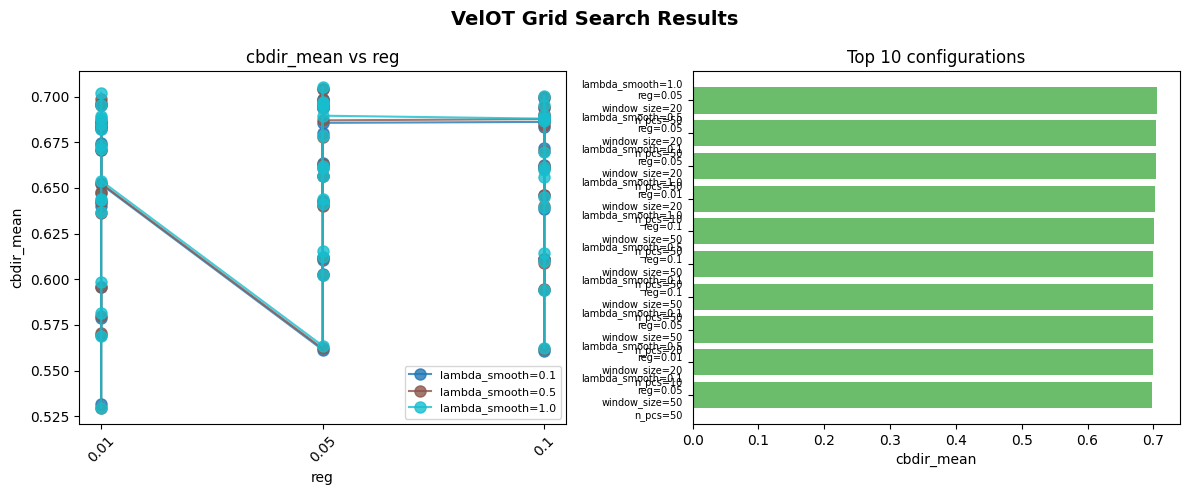

KeyError: 'n_clusters'

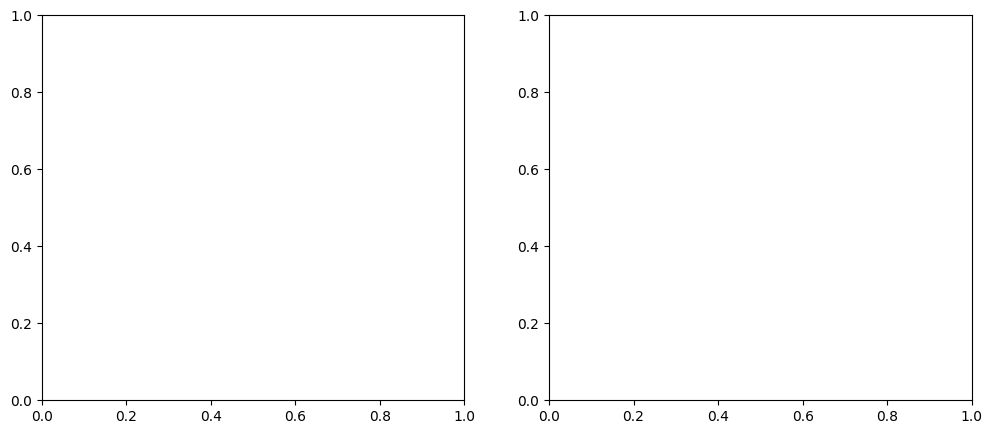

In [8]:
# View results
print(all_results.sort_values("cbdir_mean", ascending=False).head(10))
print(all_results.sort_values("iccoh_mean", ascending=False).head(10))

# Plot
velot.pl.gridsearch_results(all_results, metric="cbdir_mean", param_x="reg", param_hue="lambda_smooth")
velot.pl.gridsearch_results(all_results, metric="iccoh_mean", param_x="n_clusters", param_hue="reg")

# Save to CSV for later analysis
# all_results.to_csv("gridsearch_results.csv", index=False)

# Run the best configuration
best = all_results.loc[all_results["cbdir_mean"].idxmax()]
print(f"\nRunning best config: reg={best['reg']}, "
      f"lambda_smooth={best['lambda_smooth']}, "
      f"n_clusters={best['n_clusters']}")

velot.tl.velocity(
    adata,
    basis="X_pca",
    reg=best["reg"],
    lambda_smooth=best["lambda_smooth"],
    n_clusters=int(best["n_clusters"]),
    n_epochs=200,
)
velot.pl.velocity_raw_vs_smooth(adata, color="clusters")

In [10]:
import velot
import scvelo as scv

# Load and preprocess
adata = sc.read_h5ad("datasets/endocrinogenesis_day15.5_preprocessed.h5ad")

velot.pp.pca(adata, n_pcs=20)
velot.pp.pseudotime(adata, root_cluster="Ngn3 low EP", cluster_key="clusters")
adata.obs["clusters_id"] = adata.obs["clusters"].cat.codes

edges = [
    ('Ngn3 low EP', 'Ngn3 high EP'), 
    ('Ngn3 high EP', 'Fev+'),
    ('Fev+', 'Delta'), 
    ('Fev+', 'Beta'),
    ('Fev+','Epsilon'),
    ('Fev+','Alpha')
]

# Define search space
param_grid = {
    "reg": [0.01, 0.05],
    "lambda_smooth": [0.1, 0.5],
    "window_size": [20, 50]
}

# Run grid search (4 × 4 × 3 = 48 combinations)
results = velot.tl.gridsearch(
    adata,
    param_grid,
    cluster_edges=edges,
    cluster_key="clusters",
    fixed_params={
        "basis": "X_pca",
        "smooth": True,
        "n_epochs": 200,
        "n_clusters": None,
        "spatial_key": "clusters_id",
        "project_umap": True,
        "overlap_fraction": 0.05
        },
)

# View results
print(results.sort_values("cbdir_mean", ascending=False).head(10))
print(results.sort_values("iccoh_mean", ascending=False).head(10))

VelOT Grid Search: 8 combinations
  Parameters: ['lambda_smooth', 'reg', 'window_size']
  Fixed: {'basis': 'X_pca', 'smooth': True, 'n_epochs': 200, 'n_clusters': None, 'spatial_key': 'clusters_id', 'project_umap': True, 'overlap_fraction': 0.05}

  [1/8] {'lambda_smooth': 0.1, 'reg': 0.01, 'window_size': 20}
  Using precomputed spatial labels from 'clusters_id': 7 clusters
  Built 130 window pairs across 7 clusters (skipped 0 small clusters)
  Window size: 20, step: 19
  OT velocity computed: 2477 cells with velocity, 54 cells without (will be filled by smoothing)
  Velocity projected to UMAP (2531 cells)
    ICCoh=0.405  CBDir=0.686  (2.1s)
  [2/8] {'lambda_smooth': 0.1, 'reg': 0.01, 'window_size': 50}
  Using precomputed spatial labels from 'clusters_id': 7 clusters
  Built 51 window pairs across 7 clusters (skipped 0 small clusters)
  Window size: 50, step: 47
  OT velocity computed: 2389 cells with velocity, 142 cells without (will be filled by smoothing)
  Velocity projected to U